In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib

# ---------------------------------------------------------------
# Colorblind-safe categorical triple. Green is closest to orange
# under CVD, so the KO effect line is also dashed (redundant
# encoding) rather than relying on hue alone.
# ---------------------------------------------------------------
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#159c73"
INK, INK_MUTED = "#0b0b0b", "#898781"
BASELINE = "#c3c2b7"

OUTDIR = pathlib.Path("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/9-schematic")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
})

# Positions relative to the TSS, upstream window only (TSS at 0)
x = np.linspace(-100, 0, 400)

PEAK_POS = -70  # motif sits upstream of the TSS -> right-tailed curve

def activity(x, amp):
    return 0.15 + amp * np.exp(-((x - PEAK_POS) / 45) ** 2)

wt = activity(x, 0.75)     # WT TF activity
mut = activity(x, 0.35)    # Mutated TF activity
effect = wt - mut          # TF KO effect (loss of activity)

# Everything on one shared axes/scale so activity and KO effect
# are directly comparable in magnitude
YLIM = (0, 1.12)
YTICKS = [0, 0.5, 1.0]
XLIM = (-105, 5)

fig, ax = plt.subplots(figsize=(4.4, 3.6), dpi=140)

ax.axvline(0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax.text(0, 1.06, "TSS", ha="center", va="bottom", fontsize=8.5, color=INK_MUTED)
ax.axhline(0, color=BASELINE, lw=1, zorder=1)

ax.plot(x, wt, "-", color=BLUE, lw=1.5, zorder=3, label="WT TF")
ax.plot(x, mut, "-", color=ORANGE, lw=1.5, zorder=3, label="TF KO")
ax.plot(x, effect, "--", color=GREEN, lw=1.5, zorder=3, label="TF KO Effect")

ax.set_ylabel("Activity")
ax.set_xlabel("Distance from TSS (bp)")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_yticks(YTICKS)
ax.legend(frameon=False, loc="upper left", fontsize=9.5, handlelength=1.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(direction="out", length=3, color=BASELINE)

plt.tight_layout()

OUTDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTDIR / "fig1_tf_activity_upstream.svg", bbox_inches="tight")

plt.show()

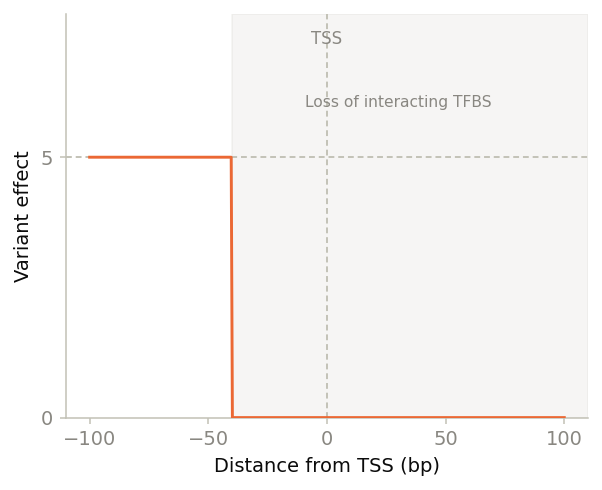

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib

ORANGE = "#eb6834"
INK, INK_MUTED = "#0b0b0b", "#898781"
BASELINE = "#c3c2b7"

OUTDIR = pathlib.Path("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/9-schematic")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
})

# ---------------------------------------------------------------
# Variant effect is constant upstream of the TSS, then drops
# sharply to 0 within the TSS-proximal window (and stays 0
# downstream, where there is no interacting TFBS to lose).
# ---------------------------------------------------------------
PLATEAU = 5   # variant effect away from the TSS
ZONE = 40     # bp upstream of TSS where the effect drops to 0

def effect_curve(x):
    return np.where(x <= -ZONE, PLATEAU, 0)

# Same -100..100 window as the other panels
x_smooth = np.linspace(-100, 100, 400)
effect_s = effect_curve(x_smooth)

fig, ax = plt.subplots(figsize=(4.4, 3.6), dpi=140)

XLIM = (-110, 110)
ax.axvspan(-ZONE, XLIM[1], color=BASELINE, alpha=0.15, zorder=0)
ax.text(30, PLATEAU * 1.18, "Loss of interacting TFBS", ha="center",
        va="bottom", fontsize=8, color=INK_MUTED)
ax.axvline(0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax.text(0, PLATEAU * 1.42, "TSS", ha="center", va="bottom",
        fontsize=8.5, color=INK_MUTED)
ax.axhline(PLATEAU, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)

ax.plot(x_smooth, effect_s, "-", color=ORANGE, lw=1.5, zorder=3)

ax.set_xlabel("Distance from TSS (bp)")
ax.set_ylabel("Variant effect")
ax.set_xlim(*XLIM)
ax.set_ylim(0, PLATEAU * 1.55)
ax.set_yticks([0, PLATEAU])
ax.set_yticklabels(["0", "5"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(direction="out", length=3, color=BASELINE)

plt.tight_layout()

OUTDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTDIR / "fig2_cooperativity.svg", bbox_inches="tight")

plt.show()